# 03 — Grouped & Time-Aware Cross-Validation

> **All About Cross-Validation**, Notebook 3 of 4.
> *What if my rows aren't independent?*

Every splitter in Notebook 02 assumed one thing: **rows are independent and shuffleable**. Real
data breaks that assumption in two common, dangerous ways:

1. **Groups** — the same entity appears in many rows (a patient with many visits, a user with
   many sessions, a sensor with many readings). Shuffle at the row level and the *same entity*
   lands in both train and test. The model recognizes the entity instead of learning the task.
2. **Time** — the data has an arrow. Training on the future to predict the past is a fantasy you
   can never reproduce in production.

Both produce **beautiful, completely fake** scores — the same leakage disease from Notebook 01,
now baked into the split itself. This notebook shows both, with the two datasets whose structure
makes the failure impossible to ignore:

- **Parkinsons Telemonitoring** — 5,875 voice recordings from **42 patients** (~139 each),
  predicting `total_UPDRS` disease severity. *Groups.*
- **Bike Sharing** — 17,379 hourly rows in chronological order. *Time.*

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from matplotlib.patches import Patch
%matplotlib inline
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 5)
RS = 42

from cv_datasets import load_parkinsons_groups, load_bike, feature_types
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score, cross_validate

X, y, groups = load_parkinsons_groups()
print(f"Parkinsons: {X.shape[0]} recordings, {groups.nunique()} patients "
      f"(~{len(groups)//groups.nunique()} recordings each)")
print(f"Target total_UPDRS: {y.min():.0f} - {y.max():.0f} (higher = more severe)")
print(f"\nOne patient's recordings are nearly identical clinical snapshots — "
      f"and share almost the same UPDRS. That's the trap.")

Parkinsons: 5875 recordings, 42 patients (~139 recordings each)
Target total_UPDRS: 7 - 55 (higher = more severe)

One patient's recordings are nearly identical clinical snapshots — and share almost the same UPDRS. That's the trap.


## Section 1 — The group-leakage disaster

We predict `total_UPDRS` with the exact same model, changing **only the splitter**:

- **`KFold(shuffle=True)`** — rows scattered at random. A patient's 139 recordings are split
  across train and test, so for almost every test recording, ~138 near-copies sit in training.
- **`GroupKFold`** — every patient is placed **entirely** in one fold. Test patients are people
  the model has *never seen*.

Watch what "changing only the splitter" does to the score.

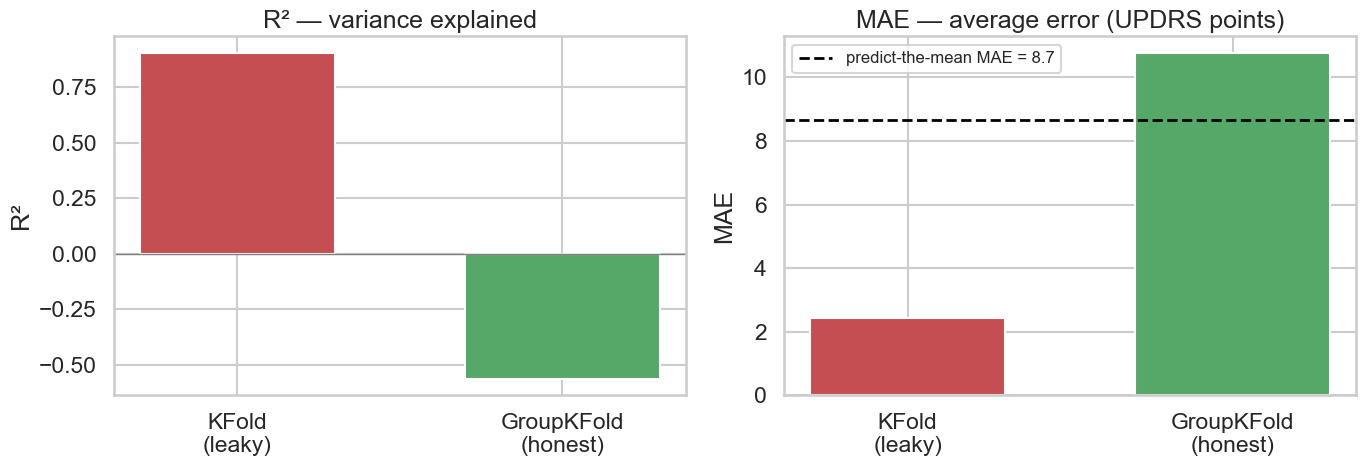

KFold (leaky) : R² = 0.907,  MAE = 2.43
GroupKFold    : R² = -0.565, MAE = 10.75
Predict-the-mean baseline MAE = 8.66


In [2]:
from sklearn.model_selection import KFold, GroupKFold

model = HistGradientBoostingRegressor(random_state=RS)

# Leaky: shuffle rows, ignore which patient they belong to.
rand = cross_validate(model, X, y, cv=KFold(5, shuffle=True, random_state=RS),
                      scoring=["r2", "neg_mean_absolute_error"])
# Honest: hold out whole patients.
grp = cross_validate(model, X, y, groups=groups, cv=GroupKFold(5),
                     scoring=["r2", "neg_mean_absolute_error"])
baseline_mae = np.mean(np.abs(y - y.mean()))   # "just predict the average UPDRS"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(["KFold\n(leaky)", "GroupKFold\n(honest)"],
            [rand["test_r2"].mean(), grp["test_r2"].mean()],
            color=["#C44E52", "#55A868"], edgecolor="white", width=0.6)
axes[0].axhline(0, color="gray", lw=1)
axes[0].set(title="R² — variance explained", ylabel="R²")
axes[1].bar(["KFold\n(leaky)", "GroupKFold\n(honest)"],
            [-rand["test_neg_mean_absolute_error"].mean(), -grp["test_neg_mean_absolute_error"].mean()],
            color=["#C44E52", "#55A868"], edgecolor="white", width=0.6)
axes[1].axhline(baseline_mae, ls="--", color="black", lw=2, label=f"predict-the-mean MAE = {baseline_mae:.1f}")
axes[1].set(title="MAE — average error (UPDRS points)", ylabel="MAE"); axes[1].legend(fontsize=12)
plt.tight_layout(); plt.show()

print(f"KFold (leaky) : R² = {rand['test_r2'].mean():.3f},  MAE = {-rand['test_neg_mean_absolute_error'].mean():.2f}")
print(f"GroupKFold    : R² = {grp['test_r2'].mean():.3f}, MAE = {-grp['test_neg_mean_absolute_error'].mean():.2f}")
print(f"Predict-the-mean baseline MAE = {baseline_mae:.2f}")

### How to read this chart 🚨

- **Leaky KFold** reports **R² ≈ 0.91, MAE ≈ 2.4**: "we predict Parkinsons severity to within
  ~2.4 points — publish it!"
- **Honest GroupKFold** reports **R² ≈ −0.57, MAE ≈ 10.8**. Negative R² means the model is
  **worse than drawing a flat line at the average** — its MAE (10.8) is *higher* than the
  predict-the-mean baseline (8.7 points).
- The model learned to **recognize patients**, not to read the disease from the voice. On a new
  patient it collapses. The random-CV number wasn't optimistic — it was **science fiction**.
- **Rule:** if the same real-world entity can appear more than once, your CV must split on that
  entity. Ask "will the things I test on share an identity with the things I trained on?"

## Section 2 — The grouped splitters

scikit-learn gives three tools for "keep each group whole":

| Splitter | What it guarantees | Use when |
|----------|-------------------|----------|
| `GroupKFold` | K folds, no group split across folds | the general case |
| `StratifiedGroupKFold` | groups whole **and** class balance preserved | classification with groups |
| `LeaveOneGroupOut` | one fold per group (K = #groups) | few groups; per-group report |

First, proof that `GroupKFold` actually keeps patients disjoint. Then `LeaveOneGroupOut` to see
how performance varies **patient by patient**.

GroupKFold: shared patients between train & test per fold = [0, 0, 0, 0, 0]  (all zero ✓)


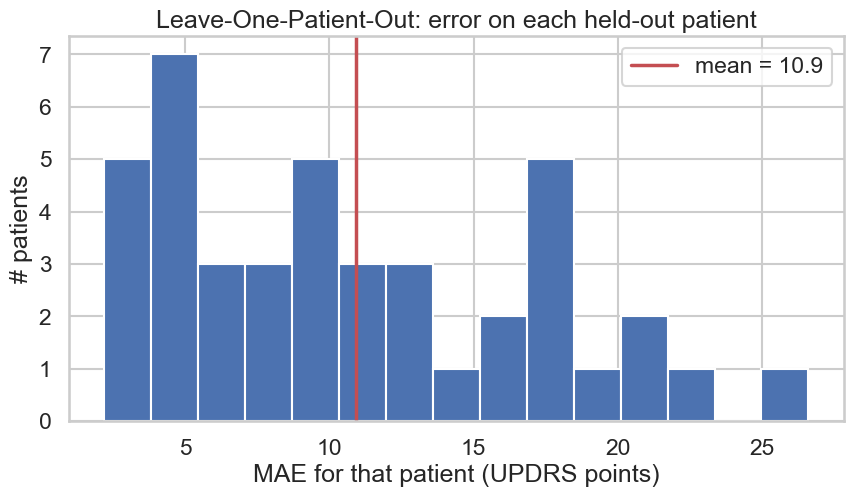

Per-patient MAE ranges 2.2 - 26.6: some patients are predictable, others hopeless. A single average would hide that.


In [3]:
from sklearn.model_selection import LeaveOneGroupOut, StratifiedGroupKFold

# Proof: no patient appears in both train and test of any GroupKFold fold.
overlaps = [len(set(groups.iloc[tr]) & set(groups.iloc[te]))
            for tr, te in GroupKFold(5).split(X, y, groups)]
print(f"GroupKFold: shared patients between train & test per fold = {overlaps}  (all zero ✓)")

# LeaveOneGroupOut: train on 41 patients, test on the 1 held out — 42 times.
logo_mae = -cross_val_score(model, X, y, groups=groups, cv=LeaveOneGroupOut(),
                            scoring="neg_mean_absolute_error")
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(logo_mae, bins=15, color="#4C72B0", edgecolor="white")
ax.axvline(logo_mae.mean(), color="#C44E52", lw=2.5, label=f"mean = {logo_mae.mean():.1f}")
ax.set(title="Leave-One-Patient-Out: error on each held-out patient",
       xlabel="MAE for that patient (UPDRS points)", ylabel="# patients"); ax.legend()
plt.show()
print(f"Per-patient MAE ranges {logo_mae.min():.1f} - {logo_mae.max():.1f}: "
      f"some patients are predictable, others hopeless. A single average would hide that.")

### How to read this — and `StratifiedGroupKFold`

- The overlap check is exactly the assurance you want in production code: **zero** shared
  patients. Put an `assert` like it in your own pipelines.
- The `LeaveOneGroupOut` histogram shows the model isn't uniformly bad — it's a *lottery per
  patient*. That spread is the real uncertainty a single averaged score erases.

`StratifiedGroupKFold` does two jobs at once — keep groups whole **and** keep class balance.
Below we binarize UPDRS into *severe vs mild* purely to illustrate it: each fold ends up with
both the right class ratio **and** zero shared patients.

In [4]:
y_severe = (y > y.median()).astype(int)      # illustration label: severe(1) vs mild(0)
sgk = StratifiedGroupKFold(5, shuffle=True, random_state=RS)
rows = []
for i, (tr, te) in enumerate(sgk.split(X, y_severe, groups)):
    rows.append({"fold": i,
                 "severe rate": round(y_severe.iloc[te].mean(), 2),
                 "shared patients": len(set(groups.iloc[tr]) & set(groups.iloc[te]))})
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nTrue severe rate = {y_severe.mean():.2f}. Every fold matches it AND shares 0 patients.")

 fold  severe rate  shared patients
    0         0.49                0
    1         0.50                0
    2         0.50                0
    3         0.51                0
    4         0.50                0

True severe rate = 0.50. Every fold matches it AND shares 0 patients.


## Section 3 — The arrow of time

Now the second way independence breaks: **temporal order**. With Bike Sharing, each row is one
hour. Shuffling rows lets the model **train on 3pm to predict 2pm of the same day** — it has
seen the future. In production the future doesn't exist yet.

`TimeSeriesSplit` enforces the rule: **train only on the past, test on the future that follows.**

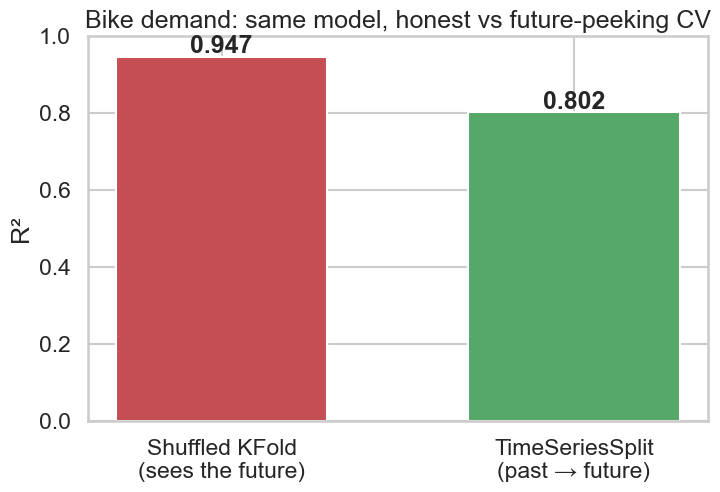

Shuffled KFold  R² = 0.947  <- inflated: trained on future hours
TimeSeriesSplit R² = 0.802  <- the honest forward-looking number
Future-peeking bought a fake +0.145 R².


In [5]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

Xb, yb = load_bike()
num_b, cat_b = feature_types(Xb)
reg = Pipeline([
    ("pre", ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat_b)],
                              remainder="passthrough")),
    ("gbr", HistGradientBoostingRegressor(random_state=RS)),
])

shuffled = cross_val_score(reg, Xb, yb, cv=KFold(5, shuffle=True, random_state=RS), scoring="r2")
timed    = cross_val_score(reg, Xb, yb, cv=TimeSeriesSplit(n_splits=5), scoring="r2")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(["Shuffled KFold\n(sees the future)", "TimeSeriesSplit\n(past → future)"],
       [shuffled.mean(), timed.mean()], color=["#C44E52", "#55A868"], edgecolor="white", width=0.6)
for i, v in enumerate([shuffled.mean(), timed.mean()]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontweight="bold")
ax.set(title="Bike demand: same model, honest vs future-peeking CV", ylabel="R²", ylim=(0, 1))
plt.show()
print(f"Shuffled KFold  R² = {shuffled.mean():.3f}  <- inflated: trained on future hours")
print(f"TimeSeriesSplit R² = {timed.mean():.3f}  <- the honest forward-looking number")
print(f"Future-peeking bought a fake +{shuffled.mean()-timed.mean():.3f} R².")

### How to read this chart

- The **0.15 R² gap** is pure temporal leakage. Shuffling scattered each day's 24 hours across
  train and test, so predicting a "held-out" hour was near-trivial interpolation between its own
  neighbors.
- `TimeSeriesSplit` is the honest estimate of *forecasting* skill: predict hours that come
  **after** everything you trained on.
- **Rule:** any data with a time arrow — forecasts, logs, prices, sensors — must never be
  shuffled. Past trains, future tests.

## Section 4 — Expanding vs sliding window

`TimeSeriesSplit` grows the training set each fold — an **expanding window** (all history so
far). The alternative is a **sliding window** (only the most recent *N* rows), which forgets old
data. Which is better depends on whether the world is **stationary**:

- **Expanding** — more data, best when patterns are stable.
- **Sliding** (`max_train_size=N`) — adapts to regime change (a new pricing model, a pandemic),
  at the cost of throwing away history.

Let's visualize both fold layouts, then compare their scores.

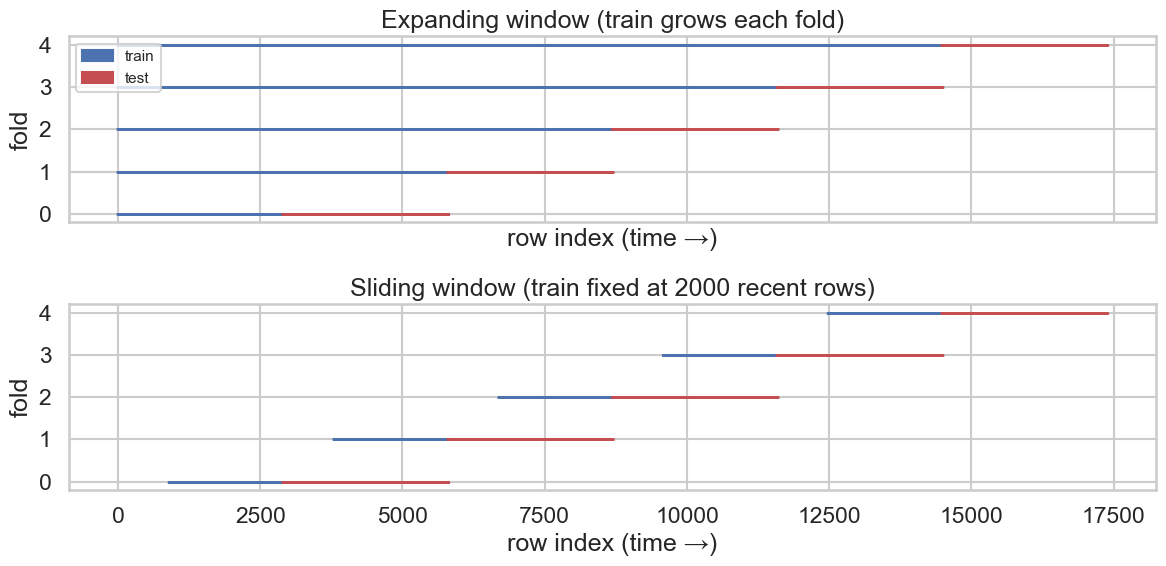

Expanding window R² = 0.802  (uses all past)
Sliding  window R² = 0.737  (last 2000 rows only)


In [6]:
def plot_folds(splitter, n, title, ax, **kw):
    for i, (tr, te) in enumerate(splitter.split(np.arange(n))):
        ax.scatter(tr, [i]*len(tr), c="#4C72B0", s=2, marker="|")
        ax.scatter(te, [i]*len(te), c="#C44E52", s=2, marker="|")
    ax.set(title=title, xlabel="row index (time →)", ylabel="fold",
           yticks=range(splitter.get_n_splits()))

n = len(Xb)
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
plot_folds(TimeSeriesSplit(n_splits=5), n, "Expanding window (train grows each fold)", axes[0])
plot_folds(TimeSeriesSplit(n_splits=5, max_train_size=2000), n,
           "Sliding window (train fixed at 2000 recent rows)", axes[1])
axes[0].legend(handles=[Patch(color="#4C72B0", label="train"), Patch(color="#C44E52", label="test")],
               loc="upper left", fontsize=11)
plt.tight_layout(); plt.show()

expand = cross_val_score(reg, Xb, yb, cv=TimeSeriesSplit(n_splits=5), scoring="r2")
slide  = cross_val_score(reg, Xb, yb, cv=TimeSeriesSplit(n_splits=5, max_train_size=2000), scoring="r2")
print(f"Expanding window R² = {expand.mean():.3f}  (uses all past)")
print(f"Sliding  window R² = {slide.mean():.3f}  (last 2000 rows only)")

### How to read this chart

- **Top (expanding):** blue train region **grows** left-to-right each fold; red test always sits
  just after it. This is `TimeSeriesSplit`'s default.
- **Bottom (sliding):** blue train is a **fixed-width** block that marches forward, discarding
  older rows.
- Here expanding wins (bike demand is fairly stationary — more data helps). On a dataset with a
  structural break you'd often see the reverse. **Always test both** when you forecast.

## Section 5 — Purged & embargoed CV (the advanced one)

Even `TimeSeriesSplit` can leak if your **label is built from a window of time**. Example: label
each hour with *"average demand over the next 24 hours."* Now the training rows in the last day
before the test block have labels computed from data that **overlaps the test period** — a
subtle leak right at the boundary.

The fix, from Marcos López de Prado's *Advances in Financial Machine Learning*:

- **Purge** — drop training rows whose label window overlaps the test set.
- **Embargo** — additionally drop a small buffer of training rows right before the test set, in
  case features are autocorrelated across the gap.

Let's build a purged + embargoed split and visualize the carved-out gap.

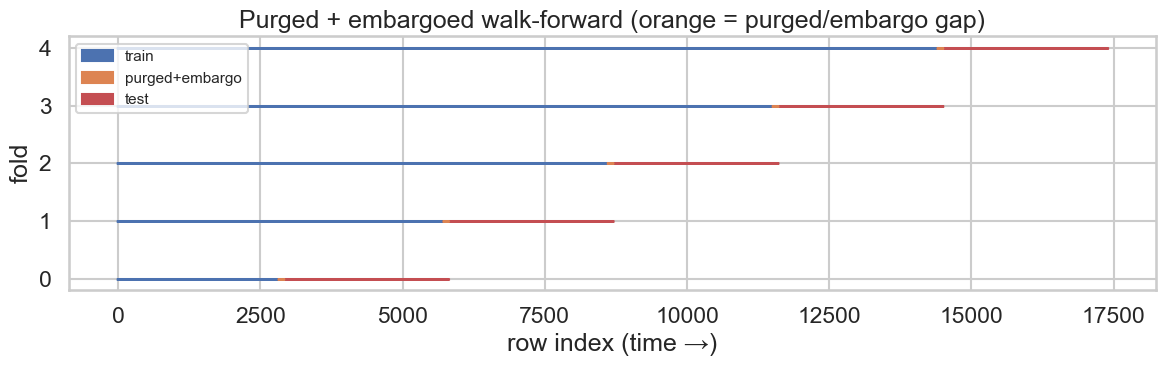

Purged walk-forward R² = 0.782
Similar to plain TimeSeriesSplit here because bike's label is a single hour (no overlap).
Purging MATTERS when the label spans time: forward returns, rolling averages, survival windows.


In [7]:
# Forward-chaining folds with a purge+embargo gap between train and test.
# purge/embargo are in rows (hours); yields (train_idx, test_idx).
def purged_walk_forward(n, n_splits=5, purge=48, embargo=24):
    fold = n // (n_splits + 1)
    for i in range(1, n_splits + 1):
        test_start, test_end = i * fold, (i + 1) * fold
        gap = purge + embargo
        train_end = max(0, test_start - gap)       # remove the overlapping + embargo rows
        train_idx = np.arange(0, train_end)
        test_idx = np.arange(test_start, min(test_end, n))
        if len(train_idx) and len(test_idx):
            yield train_idx, test_idx

fig, ax = plt.subplots(figsize=(12, 4))
for i, (tr, te) in enumerate(purged_walk_forward(n, purge=48, embargo=24)):
    ax.scatter(tr, [i]*len(tr), c="#4C72B0", s=2, marker="|")
    ax.scatter(te, [i]*len(te), c="#C44E52", s=2, marker="|")
    ax.scatter(np.arange(tr[-1]+1 if len(tr) else 0, te[0]), [i]*(te[0]-(tr[-1]+1 if len(tr) else 0)),
               c="#DD8452", s=2, marker="|")
ax.set(title="Purged + embargoed walk-forward (orange = purged/embargo gap)",
       xlabel="row index (time →)", ylabel="fold", yticks=range(5))
ax.legend(handles=[Patch(color="#4C72B0", label="train"), Patch(color="#DD8452", label="purged+embargo"),
                   Patch(color="#C44E52", label="test")], loc="upper left", fontsize=11)
plt.tight_layout(); plt.show()

# On bike, labels DON'T overlap, so the score barely moves — that's the honest finding.
scores = [reg.fit(Xb.iloc[tr], yb.iloc[tr]).score(Xb.iloc[te], yb.iloc[te])
          for tr, te in purged_walk_forward(n, purge=48, embargo=24)]
print(f"Purged walk-forward R² = {np.mean(scores):.3f}")
print("Similar to plain TimeSeriesSplit here because bike's label is a single hour (no overlap).")
print("Purging MATTERS when the label spans time: forward returns, rolling averages, survival windows.")

### How to read this chart

- The **orange band** is data thrown away on purpose: rows whose label overlaps the test window
  (**purge**) plus a safety buffer (**embargo**). Train is everything before it; test is the
  block after.
- On bike sharing the score barely changes, because each label is a single non-overlapping hour
  — and saying so honestly is the point. **Purged CV earns its keep when labels span time**:
  financial forward-return labels, rolling aggregates, "churn within 30 days," medical survival
  windows. There, skipping the purge silently leaks and inflates your backtest.

## Key takeaways

1. **Groups break row independence.** If one entity yields many rows, split on the entity
   (`GroupKFold` / `LeaveOneGroupOut`) or the same entity leaks across train/test. Parkinsons:
   R² **0.91 → −0.57** just by respecting patients.
2. **Prove disjointness** — assert zero shared groups between train and test in your own code.
3. **`StratifiedGroupKFold`** keeps groups whole *and* class balance — the grouped classifier's
   default.
4. **Time breaks it too.** Never shuffle temporal data: past trains, future tests
   (`TimeSeriesSplit`). Bike: a fake +0.15 R² vanishes once you stop peeking at the future.
5. **Expanding vs sliding window** — test both; the winner depends on whether the process drifts.
6. **Purge + embargo** when labels span time, or your backtest lies.

### Next → **04 — Model Selection with CV**
We've measured honestly. The final notebook uses CV to *choose* things — hyperparameters — with
Grid / Random / Successive-Halving / Bayesian search, and the one technique that keeps tuning
itself honest: **nested cross-validation**.